# Bài Toán Định Tuyến Xe (CVRP) bằng Tối Ưu Hóa Bầy Đàn Kiến (ACO)

Notebook này đã được gộp tất cả các module (`vrp_parser`, `local_search`, `visualizer`, `aco_vrp`) vào chung một file để bạn dễ dàng theo dõi, quan sát và chỉnh sửa code.

## 1. Import Thư Viện

In [1]:
import os
import re
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from dataclasses import dataclass
from typing import Optional, List, Tuple, Callable, Dict


## 2. Module VRP Parser (Đọc dữ liệu)

Dùng để phân tích cú pháp file `.vrp` và `.sol` từ CVRPLIB.

In [2]:
@dataclass
class VRPInstance:
    name: str
    dimension: int
    capacity: int
    coords: np.ndarray
    demands: np.ndarray
    depot: int
    optimal_value: Optional[float] = None

    def distance_matrix(self) -> np.ndarray:
        diff = self.coords[:, np.newaxis, :] - self.coords[np.newaxis, :, :]
        return np.sqrt((diff ** 2).sum(axis=-1))

    def customer_indices(self):
        return [i for i in range(self.dimension) if i != self.depot]

    def min_vehicles(self) -> int:
        total_demand = sum(self.demands[i] for i in self.customer_indices())
        return int(np.ceil(total_demand / self.capacity))

    def __str__(self):
        customers = self.dimension - 1
        total_demand = sum(self.demands[i] for i in self.customer_indices())
        min_v = self.min_vehicles()
        s = f"═══ VRP Instance: {self.name} ═══\n"
        s += f"  Số node:         {self.dimension} ({customers} khách hàng + 1 depot)\n"
        s += f"  Sức chứa xe:     {self.capacity}\n"
        s += f"  Tổng demand:     {total_demand}\n"
        s += f"  Xe tối thiểu:    ≥ {min_v}\n"
        s += f"  Depot:           node {self.depot}"
        if self.optimal_value:
            s += f"\n  Best Known (BKS): {self.optimal_value}"
        return s


def parse_vrp_file(filepath: str) -> VRPInstance:
    with open(filepath, 'r') as f:
        content = f.read()

    name_match = re.search(r'NAME\s*:\s*(.+)', content)
    name = name_match.group(1).strip() if name_match else "unknown"

    dimension = int(re.search(r'DIMENSION\s*:\s*(\d+)', content).group(1))
    capacity = int(re.search(r'CAPACITY\s*:\s*(\d+)', content).group(1))

    optimal_value = None
    comment_match = re.search(r'COMMENT\s*:\s*(.+)', content)
    if comment_match:
        opt_match = re.search(r'[Oo]ptimal\s+value\s*:\s*(\d+)', comment_match.group(1))
        if opt_match:
            optimal_value = float(opt_match.group(1))

    coords = np.zeros((dimension, 2))
    coord_match = re.search(
        r'NODE_COORD_SECTION\s*\n(.*?)(?=\n[A-Z_]+_SECTION|\nEOF)',
        content, re.DOTALL
    )
    if coord_match:
        for line in coord_match.group(1).strip().split('\n'):
            parts = line.split()
            if len(parts) >= 3:
                idx = int(parts[0]) - 1
                coords[idx] = [float(parts[1]), float(parts[2])]

    demands = np.zeros(dimension, dtype=int)
    demand_match = re.search(
        r'DEMAND_SECTION\s*\n(.*?)(?=\n[A-Z_]+_SECTION|\nEOF)',
        content, re.DOTALL
    )
    if demand_match:
        for line in demand_match.group(1).strip().split('\n'):
            parts = line.split()
            if len(parts) >= 2:
                idx = int(parts[0]) - 1
                demands[idx] = int(parts[1])

    depot = 0
    depot_match = re.search(
        r'DEPOT_SECTION\s*\n(.*?)(?=\n[A-Z_]+_SECTION|\nEOF|\Z)',
        content, re.DOTALL
    )
    if depot_match:
        for line in depot_match.group(1).strip().split('\n'):
            val = line.strip()
            if val and val != '-1':
                depot = int(val) - 1
                break

    return VRPInstance(
        name=name, dimension=dimension, capacity=capacity,
        coords=coords, demands=demands, depot=depot, optimal_value=optimal_value
    )

def parse_sol_file(filepath: str, depot: int = 0) -> list:
    routes = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.lower().startswith('route'):
                parts = line.strip().split(':')
                if len(parts) == 2:
                    customers = [int(x) - 1 for x in parts[1].split()]
                    route = [depot] + customers + [depot]
                    routes.append(route)
    return routes


## 3. Module Local Search (Tối ưu hóa cục bộ)

Chứa thuật toán `2-opt` và `Or-opt` giúp cải thiện các lộ trình mà con kiến tạo ra.

In [3]:
def two_opt_route(route: List[int], dist_matrix: np.ndarray) -> List[int]:
    route = list(route)
    n = len(route)
    improved = True

    while improved:
        improved = False
        for i in range(1, n - 2):
            for j in range(i + 1, n - 1):
                d_current = (
                    dist_matrix[route[i - 1]][route[i]]
                    + dist_matrix[route[j]][route[j + 1]]
                )
                d_new = (
                    dist_matrix[route[i - 1]][route[j]]
                    + dist_matrix[route[i]][route[j + 1]]
                )

                if d_new < d_current - 1e-10:
                    route[i : j + 1] = route[i : j + 1][::-1]
                    improved = True
    return route


def two_opt_solution(routes: List[List[int]], dist_matrix: np.ndarray) -> List[List[int]]:
    return [two_opt_route(route, dist_matrix) for route in routes]


def or_opt_route(route: List[int], dist_matrix: np.ndarray) -> List[int]:
    route = list(route)
    improved = True

    while improved:
        improved = False
        for seg_len in [1, 2, 3]:
            if improved:
                break
            for i in range(1, len(route) - seg_len):
                if i + seg_len >= len(route):
                    break
                cost_remove = (
                    dist_matrix[route[i - 1]][route[i]]
                    + dist_matrix[route[i + seg_len - 1]][route[i + seg_len]]
                    - dist_matrix[route[i - 1]][route[i + seg_len]]
                )
                best_gain = 0
                best_j = -1
                for j in range(1, len(route) - 1):
                    if i - 1 <= j <= i + seg_len:
                        continue
                    cost_insert = (
                        dist_matrix[route[j]][route[i]]
                        + dist_matrix[route[i + seg_len - 1]][route[j + 1]]
                        - dist_matrix[route[j]][route[j + 1]]
                    )
                    gain = cost_remove - cost_insert
                    if gain > best_gain + 1e-10:
                        best_gain = gain
                        best_j = j
                if best_j >= 0:
                    segment = route[i : i + seg_len]
                    new_route = route[:i] + route[i + seg_len :]
                    insert_pos = best_j if best_j < i else best_j - seg_len
                    new_route = (
                        new_route[: insert_pos + 1]
                        + segment
                        + new_route[insert_pos + 1 :]
                    )
                    route = new_route
                    improved = True
                    break
    return route


def full_local_search(routes: List[List[int]], dist_matrix: np.ndarray) -> List[List[int]]:
    improved_routes = []
    for route in routes:
        route = two_opt_route(route, dist_matrix)
        route = or_opt_route(route, dist_matrix)
        route = two_opt_route(route, dist_matrix)
        improved_routes.append(route)
    return improved_routes


## 4. Module Visualizer (Trực quan hóa)

Chứa các hàm vẽ biểu đồ lộ trình xe và biểu đồ hội tụ thuật toán.

In [4]:
def plot_instance(instance: VRPInstance, figsize=(10, 8)):
    coords = instance.coords
    fig, ax = plt.subplots(figsize=figsize)
    customers = instance.customer_indices()
    sizes = instance.demands[customers] * 5 + 20
    ax.scatter(coords[customers, 0], coords[customers, 1],
               s=sizes, c='steelblue', alpha=0.7, edgecolors='navy', label='Khách hàng')
    for c in customers:
        ax.annotate(str(c), (coords[c, 0], coords[c, 1]),
                    textcoords="offset points", xytext=(4, 4), fontsize=7, color='gray')
    depot = instance.depot
    ax.plot(coords[depot, 0], coords[depot, 1],
            'r*', markersize=20, zorder=5, label='Depot')
    ax.set_title(f'{instance.name} — {len(customers)} khách hàng, Capacity={instance.capacity}', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_routes(instance: VRPInstance, routes: List[List[int]], title: str = "CVRP Solution", figsize=(12, 9)):
    coords = instance.coords
    colors = cm.tab10(np.linspace(0, 1, max(len(routes), 1)))
    fig, ax = plt.subplots(figsize=figsize)
    for idx, route in enumerate(routes):
        route_coords = coords[route]
        load = sum(instance.demands[c] for c in route if c != instance.depot)
        ax.plot(route_coords[:, 0], route_coords[:, 1],
                '-o', color=colors[idx % 10], linewidth=1.8, markersize=6,
                label=f'Xe {idx+1} (tải={load}/{instance.capacity})', zorder=3)
    depot = instance.depot
    ax.plot(coords[depot, 0], coords[depot, 1],
            'r*', markersize=22, zorder=5, label='Depot', markeredgecolor='darkred')
    for i in range(instance.dimension):
        if i != depot:
            ax.annotate(str(i), (coords[i, 0], coords[i, 1]),
                        textcoords="offset points", xytext=(5, 5), fontsize=7, color='dimgray')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_convergence(convergence: List[float], optimal: Optional[float] = None, title: str = "Đường cong hội tụ"):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(convergence, 'b-', linewidth=1.5, label='Chi phí tốt nhất')
    if optimal:
        ax.axhline(y=optimal, color='red', linestyle='--', linewidth=1.2, label=f'BKS = {optimal}')
        final_cost = convergence[-1]
        gap = (final_cost / optimal - 1) * 100
        ax.annotate(f'Gap: {gap:.2f}%', xy=(len(convergence) - 1, final_cost),
                    xytext=(-80, 30), textcoords='offset points', fontsize=10, color='blue',
                    arrowprops=dict(arrowstyle='->', color='blue', lw=1.2))
    ax.set_title(title, fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_comparison(results: Dict[str, dict], optimal: Optional[float] = None, title: str = "So sánh"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    method_colors = ['steelblue', 'coral', 'seagreen', 'orchid']
    ax1 = axes[0]
    for i, (label, data) in enumerate(results.items()):
        ax1.plot(data['convergence'], label=label, linewidth=1.5, color=method_colors[i % len(method_colors)])
    if optimal:
        ax1.axhline(y=optimal, color='red', linestyle='--', linewidth=1, label=f'BKS = {optimal}')
    ax1.set_title('Đường cong hội tụ')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2 = axes[1]
    labels = list(results.keys())
    costs = [results[l]['cost'] for l in labels]
    bars = ax2.bar(labels, costs, color=method_colors[:len(labels)], edgecolor='gray')
    if optimal:
        ax2.axhline(y=optimal, color='red', linestyle='--', linewidth=1.2, label=f'BKS = {optimal}')
    for bar, cost in zip(bars, costs):
        gap_text = f"\n({(cost / optimal - 1) * 100:+.1f}%)" if optimal else ""
        ax2.text(bar.get_x() + bar.get_width() / 2.0, bar.get_height() + 2,
                 f'{cost:.0f}{gap_text}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax2.set_title('Chi phí cuối cùng')
    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def print_solution_summary(instance, routes, cost, stats=None, method_name="ACO"):
    print(f"\n{'═' * 60}\n  KẾT QUẢ: {method_name} — {instance.name}\n{'═' * 60}")
    print(f"  Tổng khoảng cách:  {cost:.2f}\n  Số tuyến (xe):     {len(routes)}")
    if instance.optimal_value:
        print(f"  Best Known (BKS):  {instance.optimal_value}")
        print(f"  Gap so với BKS:    {(cost / instance.optimal_value - 1) * 100:+.2f}%")
    if stats and 'runtime' in stats:
        print(f"  Thời gian:         {stats['runtime']:.2f}s")
    print(f"\n  Chi tiết từng tuyến:")
    for i, route in enumerate(routes):
        load = sum(instance.demands[c] for c in route if c != instance.depot)
        dist = sum(np.sqrt((instance.coords[route[j]] - instance.coords[route[j + 1]]) ** 2).sum() for j in range(len(route) - 1))
        print(f"    Xe {i+1:2d}: {' → '.join(map(str, route))}  │ tải={load}/{instance.capacity} │ dist={dist:.1f}")
    print(f"{'═' * 60}\n")


## 5. Module Thuật toán Kiến (ACO Core)

Trái tim của chương trình. Hỗ trợ Ant System (AS) cơ bản, Elitist, và Min-Max Ant System (MMAS).

In [5]:
class ACO_VRP:
    def __init__(self, instance: VRPInstance, n_ants: int = 50, n_iterations: int = 200,
                 alpha: float = 1.0, beta: float = 3.0, rho: float = 0.1, Q: float = 100.0,
                 use_mmas: bool = False, local_search_fn: Optional[Callable] = None,
                 elitist_weight: float = 2.0, seed: Optional[int] = None):
        if seed is not None:
            np.random.seed(seed)
        self.instance = instance
        self.dist_matrix = instance.distance_matrix()
        self.n_nodes = instance.dimension
        self.depot = instance.depot
        self.capacity = instance.capacity
        self.demands = instance.demands
        self.n_ants, self.n_iterations = n_ants, n_iterations
        self.alpha, self.beta, self.rho, self.Q = alpha, beta, rho, Q
        self.use_mmas, self.local_search_fn, self.elitist_weight = use_mmas, local_search_fn, elitist_weight

        with np.errstate(divide='ignore'):
            self.eta = 1.0 / self.dist_matrix
        np.fill_diagonal(self.eta, 0)
        self.eta[self.eta == np.inf] = 0

        self.nn_cost = self._nearest_neighbor_cost()
        tau0 = 1.0 / (self.n_nodes * self.nn_cost) if self.nn_cost > 0 else 1.0
        self.pheromone = np.full((self.n_nodes, self.n_nodes), tau0)
        if self.use_mmas:
            self.tau_max = 1.0 / (self.rho * self.nn_cost)
            self.tau_min = self.tau_max / (2.0 * self.n_nodes)
            self.pheromone = np.full((self.n_nodes, self.n_nodes), self.tau_max)

    def _nearest_neighbor_cost(self) -> float:
        unvisited = set(range(self.n_nodes)) - {self.depot}
        total_cost = 0.0
        while unvisited:
            current, load = self.depot, 0
            while unvisited:
                feasible = [j for j in unvisited if self.demands[j] <= self.capacity - load]
                if not feasible: break
                nearest = min(feasible, key=lambda j: self.dist_matrix[current][j])
                total_cost += self.dist_matrix[current][nearest]
                load += self.demands[nearest]
                current = nearest
                unvisited.remove(nearest)
            total_cost += self.dist_matrix[current][self.depot]
        return total_cost

    def solve(self, verbose: bool = True):
        best_solution, best_cost = None, np.inf
        convergence, iteration_bests = [], []
        start_time = time.time()
        for iteration in range(self.n_iterations):
            solutions = []
            for _ in range(self.n_ants):
                solution = self._construct_solution()
                if self.local_search_fn is not None:
                    solution = self.local_search_fn(solution, self.dist_matrix)
                cost = self._solution_cost(solution)
                solutions.append((solution, cost))

            iter_best_sol, iter_best_cost = min(solutions, key=lambda x: x[1])
            iteration_bests.append(iter_best_cost)
            if iter_best_cost < best_cost:
                best_solution = [route[:] for route in iter_best_sol]
                best_cost = iter_best_cost

            self._evaporate_pheromone()
            if self.use_mmas:
                self._deposit_pheromone_single(best_solution, best_cost)
                np.clip(self.pheromone, self.tau_min, self.tau_max, out=self.pheromone)
            else:
                self._deposit_pheromone_all(solutions)
                self._deposit_pheromone_single(best_solution, best_cost, weight=self.elitist_weight)

            convergence.append(best_cost)
            if verbose and (iteration + 1) % max(1, self.n_iterations // 10) == 0:
                print(f"  Iter {iteration+1:4d}/{self.n_iterations} │ Best: {best_cost:>8.2f} │ Routes: {len(best_solution)}")

        stats = {'runtime': time.time() - start_time, 'nn_cost': self.nn_cost}
        if self.instance.optimal_value:
            stats['gap_pct'] = (best_cost / self.instance.optimal_value - 1) * 100
        return best_solution, best_cost, convergence, stats

    def _construct_solution(self) -> List[List[int]]:
        unvisited = set(range(self.n_nodes)) - {self.depot}
        routes = []
        while unvisited:
            route, current_load, current = [self.depot], 0, self.depot
            while unvisited:
                feasible = [j for j in unvisited if self.demands[j] <= self.capacity - current_load]
                if not feasible: break
                next_cust = self._select_next(current, feasible)
                route.append(next_cust)
                current_load += self.demands[next_cust]
                current = next_cust
                unvisited.remove(next_cust)
            route.append(self.depot)
            routes.append(route)
        return routes

    def _select_next(self, current: int, feasible: List[int]) -> int:
        feasible_arr = np.array(feasible)
        attractiveness = (self.pheromone[current][feasible_arr] ** self.alpha) * (self.eta[current][feasible_arr] ** self.beta)
        total = attractiveness.sum()
        if total == 0: return int(np.random.choice(feasible_arr))
        return int(np.random.choice(feasible_arr, p=attractiveness / total))

    def _solution_cost(self, routes: List[List[int]]) -> float:
        return sum(self.dist_matrix[route[i]][route[i+1]] for route in routes for i in range(len(route)-1))

    def _evaporate_pheromone(self):
        self.pheromone *= (1.0 - self.rho)

    def _deposit_pheromone_all(self, solutions):
        for solution, cost in solutions:
            for route in solution:
                for i in range(len(route) - 1):
                    self.pheromone[route[i]][route[i + 1]] += self.Q / cost
                    self.pheromone[route[i + 1]][route[i]] += self.Q / cost

    def _deposit_pheromone_single(self, solution, cost, weight=1.0):
        for route in solution:
            for i in range(len(route) - 1):
                self.pheromone[route[i]][route[i + 1]] += (weight * self.Q / cost)
                self.pheromone[route[i + 1]][route[i]] += (weight * self.Q / cost)


## 6. Local Search giữa các tuyến + ACO Cải Tiến

Bản cũ chỉ tối ưu *trong từng tuyến* (2-opt, Or-opt). Ở đây thêm 3 move giữa các tuyến (relocate, swap, 2-opt*) và sửa các điểm yếu của MMAS.

Các thay đổi chính:
- Local search liên tuyến: relocate, swap, 2-opt*
- Sửa Q: MMAS nay gửi pheromone `1/cost` (trước là `100/cost`, lớn hơn `tau_max` nên bị clip hết)
- `tau_max`, `tau_min` cập nhật theo best hiện tại, `tau_min` tính theo công thức MMAS chuẩn (`p_best`)
- Luân phiên iteration-best / global-best (`gb_period`)
- Reset pheromone khi bị kẹt (`restart_after`)
- Candidate list: mỗi bước chỉ xét các khách gần nhất
- Khởi tạo `best` bằng nearest neighbor + local search
- Tính `tau^alpha * eta^beta` một lần mỗi iteration

In [6]:
# ============ Local search nhiều tuyến (inter-route) ============
def route_dist(r, d):
    return sum(d[r[i]][r[i+1]] for i in range(len(r)-1))

def inter_route_search(routes, d, demands, cap, depot=0):
    """relocate + swap + 2-opt* giữa các tuyến. Trả về routes mới (bỏ tuyến rỗng)."""
    routes = [r[:] for r in routes]
    loads = [sum(demands[c] for c in r[1:-1]) for r in routes]
    eps = 1e-9
    improved = True
    while improved:
        improved = False
        R = len(routes)
        # --- relocate: chuyển 1 khách sang tuyến khác ---
        for a in range(R):
            ra = routes[a]
            for i in range(1, len(ra) - 1):
                c = ra[i]
                rem = d[ra[i-1]][c] + d[c][ra[i+1]] - d[ra[i-1]][ra[i+1]]
                best, bb, bp = eps, -1, -1
                for b in range(R):
                    if b == a or loads[b] + demands[c] > cap:
                        continue
                    rb = routes[b]
                    for j in range(len(rb) - 1):
                        add = d[rb[j]][c] + d[c][rb[j+1]] - d[rb[j]][rb[j+1]]
                        if rem - add > best:
                            best, bb, bp = rem - add, b, j
                if bb >= 0:
                    routes[bb].insert(bp + 1, c); del ra[i]
                    loads[bb] += demands[c]; loads[a] -= demands[c]
                    improved = True; break
            if improved: break
        if improved: 
            routes, loads = _clean(routes, loads); continue
        # --- swap: đổi chỗ 2 khách ở 2 tuyến ---
        for a in range(R):
            for b in range(a + 1, R):
                ra, rb = routes[a], routes[b]
                for i in range(1, len(ra) - 1):
                    for j in range(1, len(rb) - 1):
                        ci, cj = ra[i], rb[j]
                        if loads[a] - demands[ci] + demands[cj] > cap or loads[b] - demands[cj] + demands[ci] > cap:
                            continue
                        old = d[ra[i-1]][ci] + d[ci][ra[i+1]] + d[rb[j-1]][cj] + d[cj][rb[j+1]]
                        new = d[ra[i-1]][cj] + d[cj][ra[i+1]] + d[rb[j-1]][ci] + d[ci][rb[j+1]]
                        if new < old - eps:
                            ra[i], rb[j] = cj, ci
                            loads[a] += demands[cj] - demands[ci]; loads[b] += demands[ci] - demands[cj]
                            improved = True; break
                    if improved: break
                if improved: break
            if improved: break
        if improved: continue
        # --- 2-opt*: đổi phần đuôi của 2 tuyến ---
        for a in range(R):
            for b in range(a + 1, R):
                ra, rb = routes[a], routes[b]
                pa = np.cumsum([demands[c] for c in ra[:-1]])
                pb = np.cumsum([demands[c] for c in rb[:-1]])
                for i in range(len(ra) - 1):
                    for j in range(len(rb) - 1):
                        # ra[:i+1]+rb[j+1:]  và  rb[:j+1]+ra[i+1:]
                        l1 = pa[i] + (loads[b] - pb[j]); l2 = pb[j] + (loads[a] - pa[i])
                        if l1 > cap or l2 > cap: continue
                        old = d[ra[i]][ra[i+1]] + d[rb[j]][rb[j+1]]
                        new = d[ra[i]][rb[j+1]] + d[rb[j]][ra[i+1]]
                        if new < old - eps:
                            na = ra[:i+1] + rb[j+1:]; nb = rb[:j+1] + ra[i+1:]
                            routes[a], routes[b] = na, nb
                            loads[a], loads[b] = l1, l2
                            improved = True; break
                    if improved: break
                if improved: break
            if improved: break
        routes, loads = _clean(routes, loads)
    return routes

def _clean(routes, loads):
    keep = [k for k, r in enumerate(routes) if len(r) > 2]
    return [routes[k] for k in keep], [loads[k] for k in keep]

def full_local_search_v2(routes, d, demands, cap, depot=0):
    """intra (2-opt + Or-opt) -> inter (relocate/swap/2-opt*) -> lặp tới khi hết cải thiện"""
    prev = sum(route_dist(r, d) for r in routes)
    while True:
        routes = full_local_search(routes, d)
        routes = inter_route_search(routes, d, demands, cap, depot)
        cur = sum(route_dist(r, d) for r in routes)
        if cur > prev - 1e-9: break
        prev = cur
    return routes


class ACO_VRP_Improved:
    def __init__(self, instance, n_ants=30, n_iterations=100, alpha=1.0, beta=3.0, rho=0.2,
                 cand_size=12, p_best=0.05, gb_period=5, restart_after=30,
                 use_local_search=True, seed=None):
        self.rng = np.random.default_rng(seed)
        self.inst = instance
        self.d = instance.distance_matrix()
        self.n = instance.dimension; self.depot = instance.depot
        self.cap = instance.capacity; self.dem = instance.demands
        self.n_ants, self.n_iter = n_ants, n_iterations
        self.alpha, self.beta, self.rho = alpha, beta, rho
        self.p_best, self.gb_period, self.restart_after = p_best, gb_period, restart_after
        self.use_ls = use_local_search

        with np.errstate(divide='ignore'):
            self.eta = 1.0 / self.d
        self.eta[~np.isfinite(self.eta)] = 0
        # danh sách ứng viên: cand_size khách gần nhất của mỗi node
        order = np.argsort(self.d, axis=1)
        self.cand = [[j for j in order[i] if j != i and j != self.depot][:cand_size] for i in range(self.n)]
        self.avg_choices = max(2, cand_size / 2)

    # ---- khởi tạo bằng nearest neighbor + local search ----
    def _nn_solution(self):
        unv = set(range(self.n)) - {self.depot}; routes = []
        while unv:
            r, load, cur = [self.depot], 0, self.depot
            while True:
                f = [j for j in unv if self.dem[j] <= self.cap - load]
                if not f: break
                nx = min(f, key=lambda j: self.d[cur][j])
                r.append(nx); load += self.dem[nx]; cur = nx; unv.remove(nx)
            r.append(self.depot); routes.append(r)
        return routes

    def _cost(self, routes):
        return sum(route_dist(r, self.d) for r in routes)

    def _local_search(self, routes):
        return full_local_search_v2(routes, self.d, self.dem, self.cap, self.depot)

    def _set_limits(self, best_cost):
        self.tau_max = 1.0 / (self.rho * best_cost)
        pn = self.p_best ** (1.0 / self.n)
        self.tau_min = min(self.tau_max, self.tau_max * (1 - pn) / ((self.avg_choices - 1) * pn))

    def _construct(self):
        unv = np.ones(self.n, dtype=bool); unv[self.depot] = False
        left = self.n - 1; routes = []
        while left > 0:
            r, load, cur = [self.depot], 0, self.depot
            while left > 0:
                # ưu tiên khách trong candidate list, nếu không có ai khả thi thì xét tất cả
                f = [j for j in self.cand[cur] if unv[j] and self.dem[j] <= self.cap - load]
                if not f:
                    f = [j for j in np.flatnonzero(unv) if self.dem[j] <= self.cap - load]
                    if not f: break
                f = np.array(f)
                p = self.choice[cur, f]; s = p.sum()
                nx = int(self.rng.choice(f, p=p / s)) if s > 0 else int(self.rng.choice(f))
                r.append(nx); load += self.dem[nx]; cur = nx; unv[nx] = False; left -= 1
            r.append(self.depot); routes.append(r)
        return routes

    def _deposit(self, sol, cost):
        amt = 1.0 / cost
        for r in sol:
            for i in range(len(r) - 1):
                self.tau[r[i], r[i+1]] += amt; self.tau[r[i+1], r[i]] += amt

    def solve(self, verbose=True):
        t0 = time.time()
        best = self._nn_solution()
        if self.use_ls: best = self._local_search(best)
        best_cost = self._cost(best)
        self._set_limits(best_cost)
        self.tau = np.full((self.n, self.n), self.tau_max)
        conv, stagn = [], 0
        for it in range(self.n_iter):
            self.choice = (self.tau ** self.alpha) * (self.eta ** self.beta)   # tính 1 lần / iteration
            sols = []
            for _ in range(self.n_ants):
                s = self._construct()
                if self.use_ls: s = self._local_search(s)
                sols.append((s, self._cost(s)))
            ib, ib_cost = min(sols, key=lambda x: x[1])
            if ib_cost < best_cost - 1e-9:
                best, best_cost, stagn = [r[:] for r in ib], ib_cost, 0
                self._set_limits(best_cost)           # cập nhật tau_max / tau_min theo best mới
            else:
                stagn += 1
            self.tau *= (1 - self.rho)
            # luân phiên iteration-best và global-best
            if (it + 1) % self.gb_period == 0: self._deposit(best, best_cost)
            else: self._deposit(ib, ib_cost)
            np.clip(self.tau, self.tau_min, self.tau_max, out=self.tau)
            if stagn >= self.restart_after:            # kẹt lâu -> reset pheromone
                self.tau[:] = self.tau_max; stagn = 0
            conv.append(best_cost)
            if verbose and (it + 1) % max(1, self.n_iter // 10) == 0:
                print(f"  Iter {it+1:4d}/{self.n_iter} │ Best: {best_cost:>8.2f} │ Routes: {len(best)}")
        stats = {'runtime': time.time() - t0}
        if self.inst.optimal_value: stats['gap_pct'] = (best_cost / self.inst.optimal_value - 1) * 100
        return best, best_cost, conv, stats


## 7. Khởi tạo & Tải Dữ Liệu

Tải dataset và vẽ sơ đồ vị trí các khách hàng cùng Depot.

═══ VRP Instance: A-n32-k5 ═══
  Số node:         32 (31 khách hàng + 1 depot)
  Sức chứa xe:     100
  Tổng demand:     410
  Xe tối thiểu:    ≥ 5
  Depot:           node 0
  Best Known (BKS): 784.0


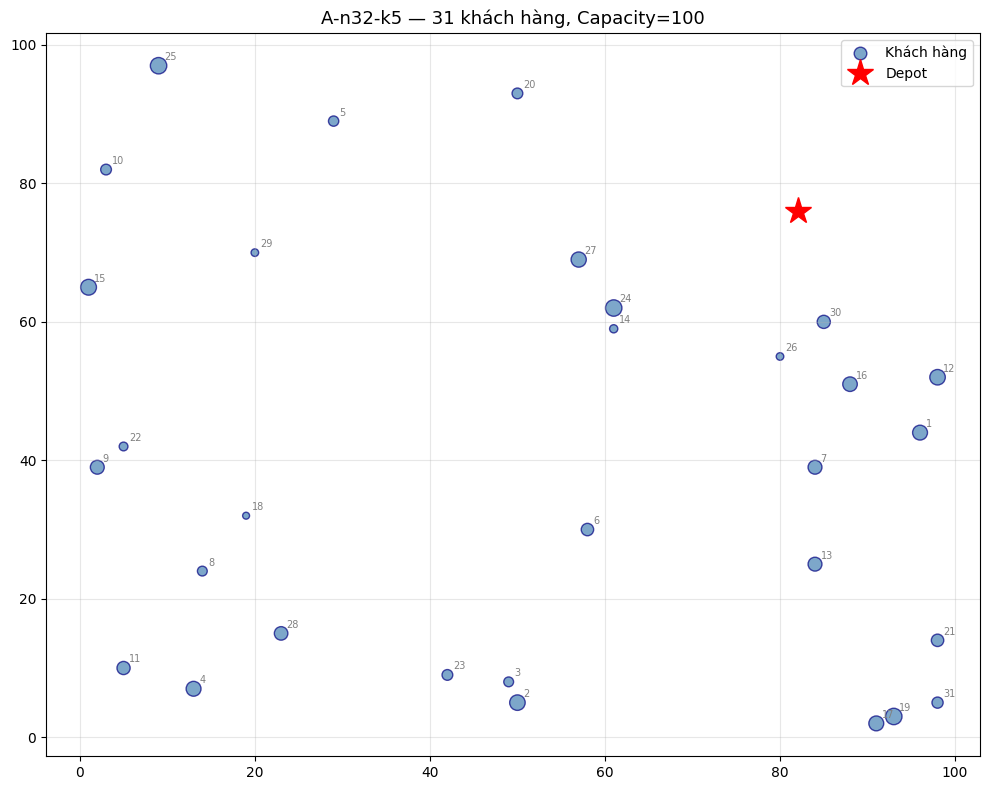

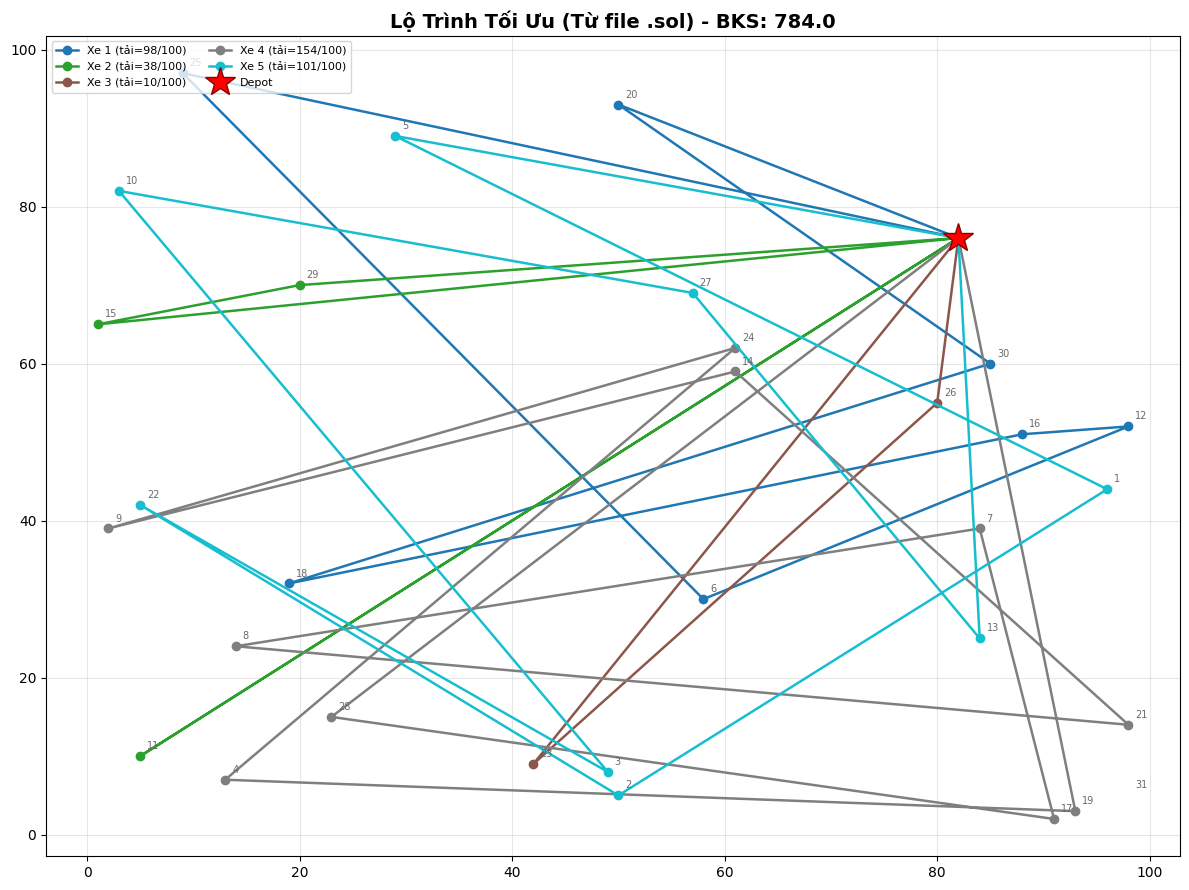

In [7]:
DATA_FILE = 'data/A-n32-k5.vrp'
SOL_FILE = 'data/A-n32-k5.sol'

if not os.path.exists(DATA_FILE):
    print(f"⚠️ Không tìm thấy file {DATA_FILE}. Vui lòng tải về và đặt vào thư mục data/")
else:
    vrp_instance = parse_vrp_file(DATA_FILE)
    print(vrp_instance)
    plot_instance(vrp_instance)

    if os.path.exists(SOL_FILE):
        optimal_routes = parse_sol_file(SOL_FILE, depot=vrp_instance.depot)
        plot_routes(vrp_instance, optimal_routes, title=f"Lộ Trình Tối Ưu (Từ file .sol) - BKS: {vrp_instance.optimal_value}")
    else:
        print(f"ℹ️ Nếu bạn muốn xem đồ thị lộ trình tối ưu, hãy tải thêm file {SOL_FILE} vào thư mục data/")


## 8. Chạy ACO Cơ Bản

Chỉ áp dụng Ràng Buộc Sức Chứa (không dùng MMAS, không dùng Local Search).

Đang chạy ACO Cơ bản...
  Iter   10/100 │ Best:   988.11 │ Routes: 5
  Iter   20/100 │ Best:   982.78 │ Routes: 5
  Iter   30/100 │ Best:   959.77 │ Routes: 5
  Iter   40/100 │ Best:   882.96 │ Routes: 5
  Iter   50/100 │ Best:   882.96 │ Routes: 5
  Iter   60/100 │ Best:   882.96 │ Routes: 5
  Iter   70/100 │ Best:   851.13 │ Routes: 5
  Iter   80/100 │ Best:   851.13 │ Routes: 5
  Iter   90/100 │ Best:   851.13 │ Routes: 5
  Iter  100/100 │ Best:   851.13 │ Routes: 5

════════════════════════════════════════════════════════════
  KẾT QUẢ: ACO Cơ Bản — A-n32-k5
════════════════════════════════════════════════════════════
  Tổng khoảng cách:  851.13
  Số tuyến (xe):     5
  Best Known (BKS):  784.0
  Gap so với BKS:    +8.56%
  Thời gian:         2.49s

  Chi tiết từng tuyến:
    Xe  1: 0 → 27 → 24 → 14 → 26 → 30 → 16 → 1 → 0  │ tải=100/100 │ dist=152.0
    Xe  2: 0 → 3 → 2 → 23 → 28 → 4 → 11 → 8 → 18 → 22 → 29 → 0  │ tải=96/100 │ dist=342.0
    Xe  3: 0 → 19 → 17 → 31 → 21 → 13 → 7 → 

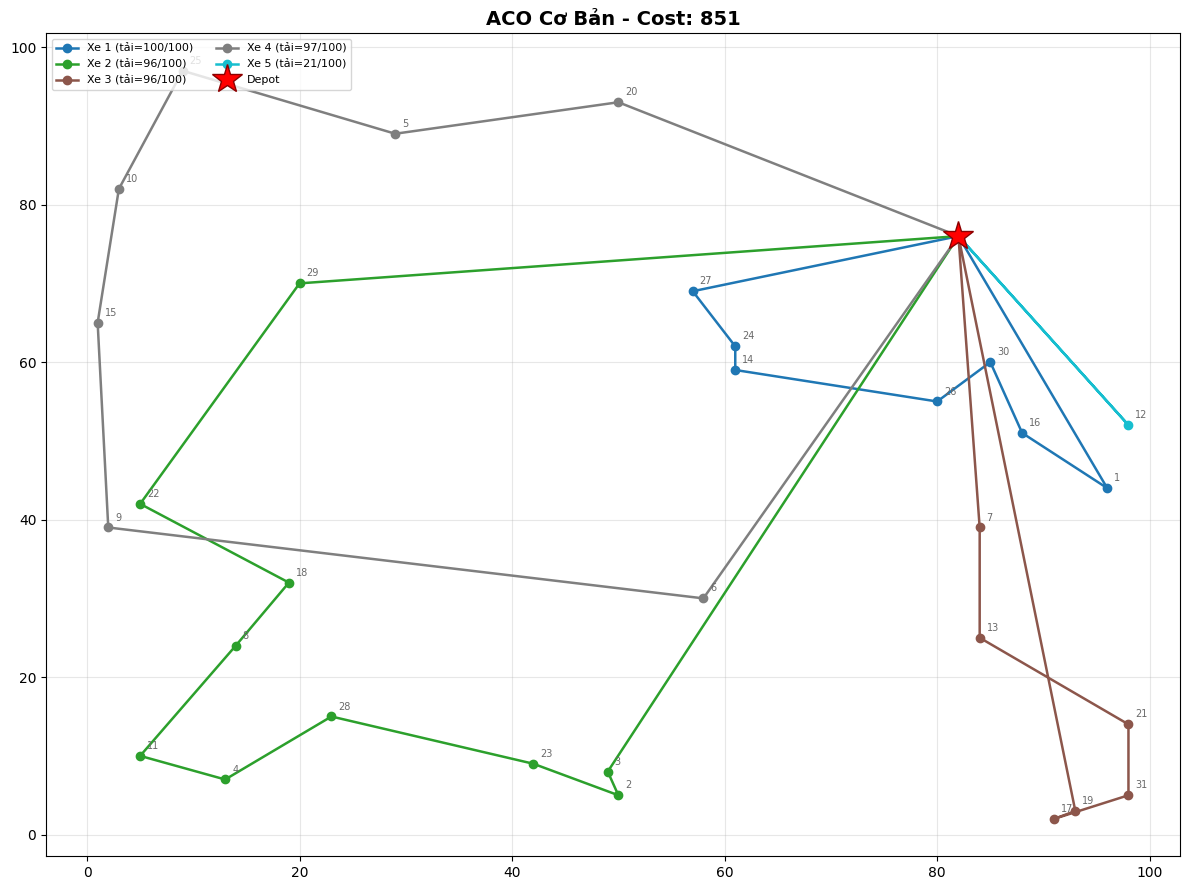

In [8]:
if os.path.exists(DATA_FILE):
    print("Đang chạy ACO Cơ bản...")
    aco_basic = ACO_VRP(
        instance=vrp_instance, 
        n_ants=30, 
        n_iterations=100, 
        alpha=1.0, 
        beta=3.0, 
        rho=0.1, 
        use_mmas=False,
        local_search_fn=None,
        seed=42
    )
    
    routes_basic, cost_basic, conv_basic, stats_basic = aco_basic.solve(verbose=True)
    print_solution_summary(vrp_instance, routes_basic, cost_basic, stats_basic, "ACO Cơ Bản")
    plot_routes(vrp_instance, routes_basic, title=f"ACO Cơ Bản - Cost: {cost_basic:.0f}")


## 9. Chạy ACO Nâng Cao

Áp dụng MMAS (Min-Max Ant System) và 2-opt/Or-opt Local Search để tối ưu lộ trình.

Đang chạy ACO Nâng cao...
  Iter   10/100 │ Best:   910.14 │ Routes: 5
  Iter   20/100 │ Best:   877.08 │ Routes: 5
  Iter   30/100 │ Best:   849.59 │ Routes: 5
  Iter   40/100 │ Best:   849.59 │ Routes: 5
  Iter   50/100 │ Best:   832.14 │ Routes: 5
  Iter   60/100 │ Best:   832.14 │ Routes: 5
  Iter   70/100 │ Best:   821.58 │ Routes: 5
  Iter   80/100 │ Best:   821.58 │ Routes: 5
  Iter   90/100 │ Best:   817.24 │ Routes: 5
  Iter  100/100 │ Best:   817.24 │ Routes: 5

════════════════════════════════════════════════════════════
  KẾT QUẢ: ACO Nâng Cao — A-n32-k5
════════════════════════════════════════════════════════════
  Tổng khoảng cách:  817.24
  Số tuyến (xe):     5
  Best Known (BKS):  784.0
  Gap so với BKS:    +4.24%
  Thời gian:         5.20s

  Chi tiết từng tuyến:
    Xe  1: 0 → 29 → 18 → 11 → 4 → 28 → 23 → 2 → 3 → 6 → 26 → 0  │ tải=100/100 │ dist=314.0
    Xe  2: 0 → 24 → 14 → 16 → 1 → 12 → 30 → 0  │ tải=99/100 │ dist=138.0
    Xe  3: 0 → 20 → 5 → 25 → 10 → 15 → 22 → 9

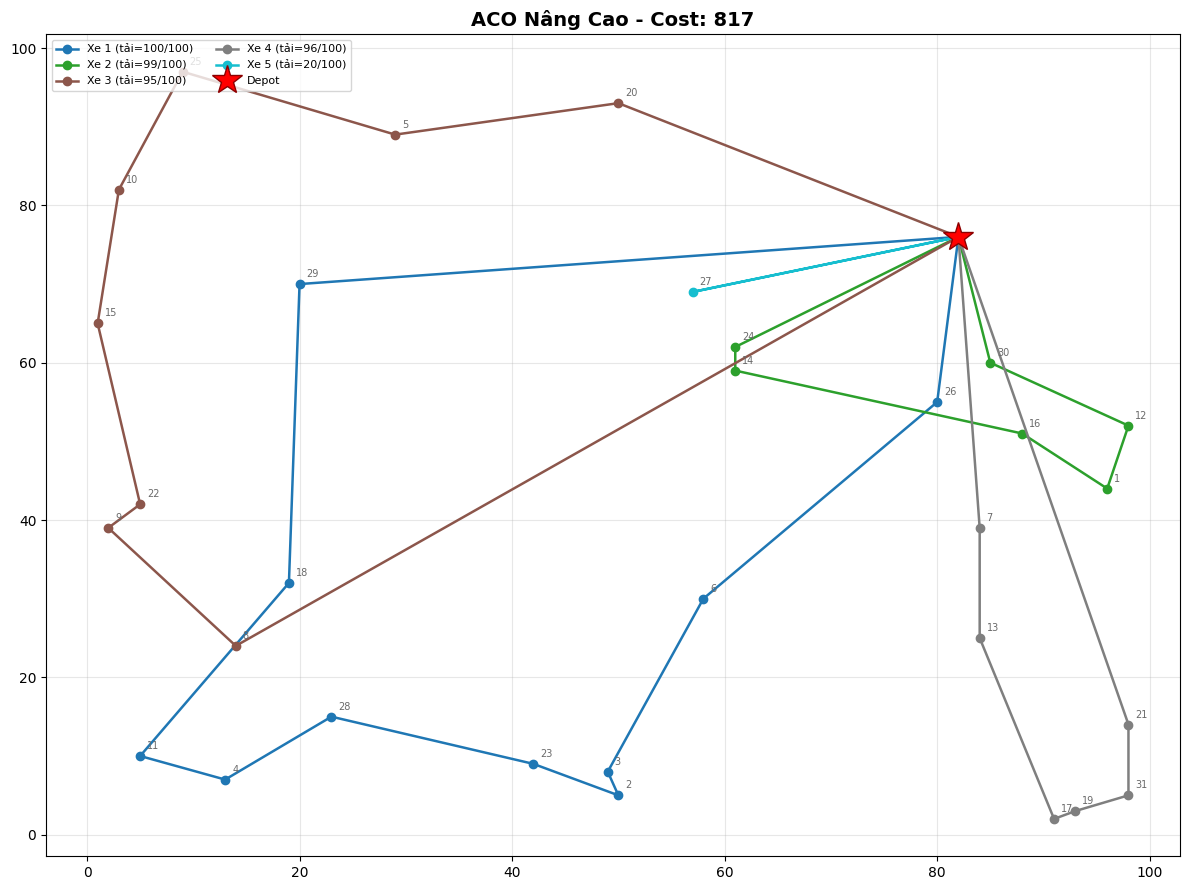

In [9]:
if os.path.exists(DATA_FILE):
    print("Đang chạy ACO Nâng cao...")
    aco_adv = ACO_VRP(
        instance=vrp_instance, 
        n_ants=30, 
        n_iterations=100, 
        alpha=1.0, 
        beta=3.0, 
        rho=0.1, 
        use_mmas=True,
        local_search_fn=full_local_search,
        seed=42
    )
    
    routes_adv, cost_adv, conv_adv, stats_adv = aco_adv.solve(verbose=True)
    print_solution_summary(vrp_instance, routes_adv, cost_adv, stats_adv, "ACO Nâng Cao")
    plot_routes(vrp_instance, routes_adv, title=f"ACO Nâng Cao - Cost: {cost_adv:.0f}")


## 10. Chạy ACO Cải Tiến

Chạy lâu hơn bản nâng cao vì local search nặng hơn (đổi lại cost tốt hơn).

Đang chạy ACO Cải tiến...
  Iter   10/100 │ Best:   787.08 │ Routes: 5
  Iter   20/100 │ Best:   787.08 │ Routes: 5
  Iter   30/100 │ Best:   787.08 │ Routes: 5
  Iter   40/100 │ Best:   787.08 │ Routes: 5
  Iter   50/100 │ Best:   787.08 │ Routes: 5
  Iter   60/100 │ Best:   787.08 │ Routes: 5
  Iter   70/100 │ Best:   787.08 │ Routes: 5
  Iter   80/100 │ Best:   787.08 │ Routes: 5
  Iter   90/100 │ Best:   787.08 │ Routes: 5
  Iter  100/100 │ Best:   787.08 │ Routes: 5

════════════════════════════════════════════════════════════
  KẾT QUẢ: ACO Cải Tiến — A-n32-k5
════════════════════════════════════════════════════════════
  Tổng khoảng cách:  787.08
  Số tuyến (xe):     5
  Best Known (BKS):  784.0
  Gap so với BKS:    +0.39%
  Thời gian:         48.90s

  Chi tiết từng tuyến:
    Xe  1: 0 → 27 → 24 → 0  │ tải=44/100 │ dist=78.0
    Xe  2: 0 → 6 → 3 → 2 → 23 → 4 → 11 → 28 → 14 → 0  │ tải=98/100 │ dist=302.0
    Xe  3: 0 → 18 → 8 → 9 → 22 → 15 → 29 → 10 → 25 → 5 → 20 → 0  │ tải=98/1

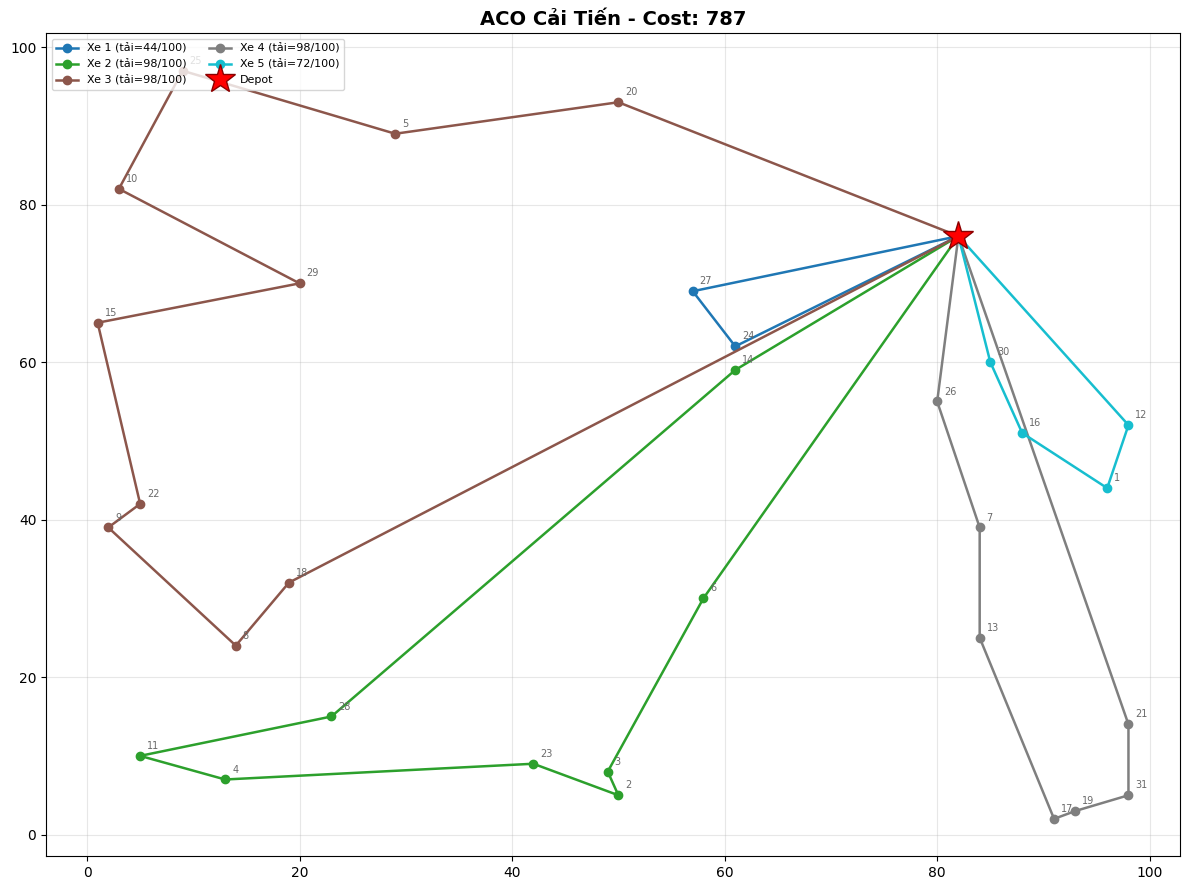

In [10]:
if os.path.exists(DATA_FILE):
    print("Đang chạy ACO Cải tiến...")
    aco_imp = ACO_VRP_Improved(
        instance=vrp_instance,
        n_ants=30,
        n_iterations=100,
        alpha=1.0,
        beta=3.0,
        rho=0.2,
        cand_size=12,
        gb_period=5,
        restart_after=30,
        seed=42
    )

    routes_imp, cost_imp, conv_imp, stats_imp = aco_imp.solve(verbose=True)
    print_solution_summary(vrp_instance, routes_imp, cost_imp, stats_imp, "ACO Cải Tiến")
    plot_routes(vrp_instance, routes_imp, title=f"ACO Cải Tiến - Cost: {cost_imp:.0f}")

## 11. Tổng Kết và So Sánh

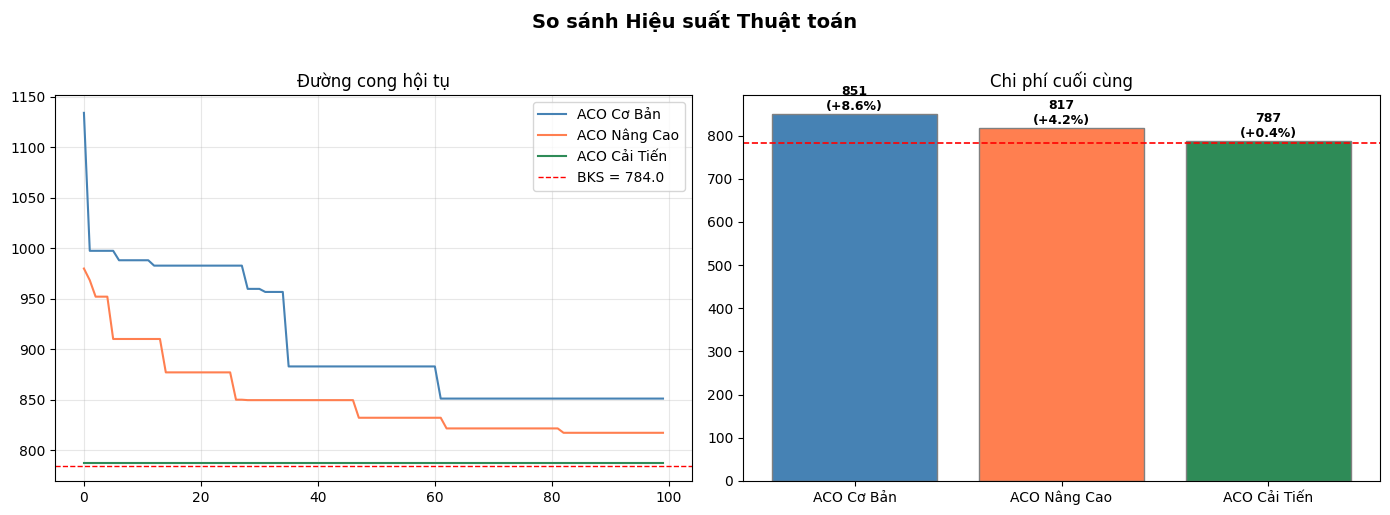

In [11]:
if os.path.exists(DATA_FILE):
    results = {
        'ACO Cơ Bản': {'convergence': conv_basic, 'cost': cost_basic},
        'ACO Nâng Cao': {'convergence': conv_adv, 'cost': cost_adv},
        'ACO Cải Tiến': {'convergence': conv_imp, 'cost': cost_imp}
    }
    plot_comparison(results, optimal=vrp_instance.optimal_value, title="So sánh Hiệu suất Thuật toán")
